In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
import warnings
warnings.simplefilter(action='ignore',category=FutureWarning)

In [42]:
data_set=pd.read_csv('raw_rfm_sales_transactions_30000.csv')

In [43]:
data_set.head()

,Transaction ID,Date,Product ID,Product Name,Product Category,Quantity,PPU,Amount
0,Customer-001,Yangon,NaN,NaN,NaN,NaN,NaN,NaN
1,T000001,01.01.2025,PROD-008,Executive Ballpoint Pen Box,Office Supplies,8.0,"70,000","560,000"
2,T000002,01.01.2025,PROD-002,Wireless Mechanical Keyboard,Electronics,10.0,"380,000","3,800,000"
3,T000003,01.01.2025,PROD-004,Standing Desk Converter,Furniture,6.0,"500,000","3,000,000"
4,T000004,01.01.2025,PROD-006,A4 Printer Paper (500 Sheets),Office Supplies,3.0,"25,500","76,500"


In [44]:
data_set.tail()

,Transaction ID,Date,Product ID,Product Name,Product Category,Quantity,PPU,Amount
30095,T029544,24.06.2025,PROD-007,USB-C Docking Station,Electronics,4.0,"340,000","1,360,000"
30096,T029545,24.06.2025,PROD-006,A4 Printer Paper (500 Sheets),Office Supplies,2.0,"25,500","51,000"
30097,T029612,25.06.2025,PROD-008,Executive Ballpoint Pen Box,Office Supplies,10.0,"70,000","700,000"
30098,T029681,26.06.2025,PROD-003,27-inch 4K Monitor,Electronics,6.0,"1,200,000","7,200,000"
30099,T029829,28.06.2025,PROD-006,A4 Printer Paper (500 Sheets),Office Supplies,6.0,"25,500","153,000"


In [45]:
data_set.isnull().sum()

Transaction ID        0
Date                  0
Product ID          100
Product Name        100
Product Category    100
Quantity            100
PPU                 100
Amount              100
dtype: int64

In [46]:
data_set.iloc[50:100]

,Transaction ID,Date,Product ID,Product Name,Product Category,Quantity,PPU,Amount
50,T009494,01.02.2025,PROD-001,Ergonomic Mesh Chair,Furniture,10.0,"750,000","7,500,000"
51,T009817,02.02.2025,PROD-005,Noise-Cancelling Headphones,Electronics,2.0,"900,000","1,800,000"
52,T009818,02.02.2025,PROD-004,Standing Desk Converter,Furniture,2.0,"500,000","1,000,000"
53,T009819,02.02.2025,PROD-004,Standing Desk Converter,Furniture,3.0,"500,000","1,500,000"
54,T011062,06.02.2025,PROD-010,Webcam 1080p HD,Electronics,1.0,"180,000","180,000"
55,T011063,06.02.2025,PROD-002,Wireless Mechanical Keyboard,Electronics,7.0,"380,000","2,660,000"
56,T011364,07.02.2025,PROD-005,Noise-Cancelling Headphones,Electronics,2.0,"900,000","1,800,000"
57,T011658,08.02.2025,PROD-007,USB-C Docking Station,Electronics,10.0,"340,000","3,400,000"
58,T011659,08.02.2025,PROD-007,USB-C Docking Station,Electronics,9.0,"340,000","3,060,000"
59,T012272,10.02.2025,PROD-002,Wireless Mechanical Keyboard,Electronics,8.0,"380,000","3,040,000"


In [47]:
print(data_set[['Date','Amount']].head(10))
print(data_set['Date'].dtype)
print(data_set['Amount'].dtype)

         Date     Amount
0      Yangon        NaN
1  01.01.2025    560,000
2  01.01.2025  3,800,000
3  01.01.2025  3,000,000
4  01.01.2025     76,500
5  02.01.2025  3,800,000
6  03.01.2025    700,000
7  03.01.2025     25,500
8  04.01.2025  4,500,000
9  05.01.2025  1,950,000
object
object


In [48]:
data_set['Product ID'].unique()

array([nan, 'PROD-008', 'PROD-002', 'PROD-004', 'PROD-006', 'PROD-001',
       'PROD-009', 'PROD-010', 'PROD-005', 'PROD-003', 'PROD-007'],
      dtype=object)

In [49]:
data_set[data_set['Product ID'].isnull()]

,Transaction ID,Date,Product ID,Product Name,Product Category,Quantity,PPU,Amount
0,Customer-001,Yangon,NaN,NaN,NaN,NaN,NaN,NaN
323,Customer-002,Bago,NaN,NaN,NaN,NaN,NaN,NaN
586,Customer-003,Naypyitaw,NaN,NaN,NaN,NaN,NaN,NaN
874,Customer-004,Taunggyi,NaN,NaN,NaN,NaN,NaN,NaN
1193,Customer-005,Bago,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
28595,Customer-096,Taunggyi,NaN,NaN,NaN,NaN,NaN,NaN
28909,Customer-097,Yangon,NaN,NaN,NaN,NaN,NaN,NaN
29205,Customer-098,Taunggyi,NaN,NaN,NaN,NaN,NaN,NaN
29511,Customer-099,Mandalay,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
data_set.dropna(inplace=True)

In [51]:
data_set.isnull().sum()

Transaction ID      0
Date                0
Product ID          0
Product Name        0
Product Category    0
Quantity            0
PPU                 0
Amount              0
dtype: int64

In [52]:
# Product Category Count
data_set['Product Category'].value_counts()

Product Category
Electronics        15047
Furniture           8916
Office Supplies     6037
Name: count, dtype: int64

In [53]:
# Produc NAme Count
data_set['Product Name'].value_counts()

Product Name
Webcam 1080p HD                  3110
A4 Printer Paper (500 Sheets)    3082
Wireless Mechanical Keyboard     3017
Adjustable Monitor Arm           3001
Noise-Cancelling Headphones      2983
Standing Desk Converter          2982
USB-C Docking Station            2981
27-inch 4K Monitor               2956
Executive Ballpoint Pen Box      2955
Ergonomic Mesh Chair             2933
Name: count, dtype: int64

In [54]:
# Product ID Count
data_set['Product ID'].value_counts()

Product ID
PROD-010    3110
PROD-006    3082
PROD-002    3017
PROD-009    3001
PROD-005    2983
PROD-004    2982
PROD-007    2981
PROD-003    2956
PROD-008    2955
PROD-001    2933
Name: count, dtype: int64

In [55]:
data_set.groupby('Product ID')[['Amount','Quantity']].sum()

,Amount,Quantity
Product ID,,
PROD-001,"4,500,0006,000,0001,500,0004,500,0007,500,0005...",16083.0
PROD-002,"3,800,0003,800,0002,280,0001,900,000760,0002,2...",16841.0
PROD-003,"10,800,0006,000,0001,200,0002,400,0003,600,000...",16212.0
PROD-004,"3,000,0001,000,0003,500,0004,500,0001,000,0002...",16419.0
PROD-005,"900,0004,500,0006,300,0007,200,0008,100,0001,8...",16133.0
PROD-006,"76,50025,50025,500229,500229,50076,500178,5001...",16969.0
PROD-007,"2,380,000680,0003,400,0003,060,0002,720,000340...",16349.0
PROD-008,"560,000700,000630,00070,000140,000560,00070,00...",16153.0
PROD-009,"1,950,0001,365,0001,755,000780,000195,0001,950...",16512.0


In [56]:
data_set.groupby('Product Name')[['Quantity','Amount']].sum()

,Quantity,Amount
Product Name,,
27-inch 4K Monitor,16212.0,"10,800,0006,000,0001,200,0002,400,0003,600,000..."
A4 Printer Paper (500 Sheets),16969.0,"76,50025,50025,500229,500229,50076,500178,5001..."
Adjustable Monitor Arm,16512.0,"1,950,0001,365,0001,755,000780,000195,0001,950..."
Ergonomic Mesh Chair,16083.0,"4,500,0006,000,0001,500,0004,500,0007,500,0005..."
Executive Ballpoint Pen Box,16153.0,"560,000700,000630,00070,000140,000560,00070,00..."
Noise-Cancelling Headphones,16133.0,"900,0004,500,0006,300,0007,200,0008,100,0001,8..."
Standing Desk Converter,16419.0,"3,000,0001,000,0003,500,0004,500,0001,000,0002..."
USB-C Docking Station,16349.0,"2,380,000680,0003,400,0003,060,0002,720,000340..."
Webcam 1080p HD,17031.0,"1,800,000180,000540,000360,0001,800,000180,000..."


In [57]:
data_set.groupby('Product Category')[['Amount','Quantity']].sum()

,Amount,Quantity
Product Category,,
Electronics,"3,800,0003,800,0001,800,000900,0004,500,00010,...",82566.0
Furniture,"3,000,0004,500,0001,950,0001,365,0001,755,0006...",49014.0
Office Supplies,"560,00076,500700,00025,50025,500630,000229,500...",33122.0


DATA VISUALIZATION

Bar Chart:<br>
To compare values between different categories<br>

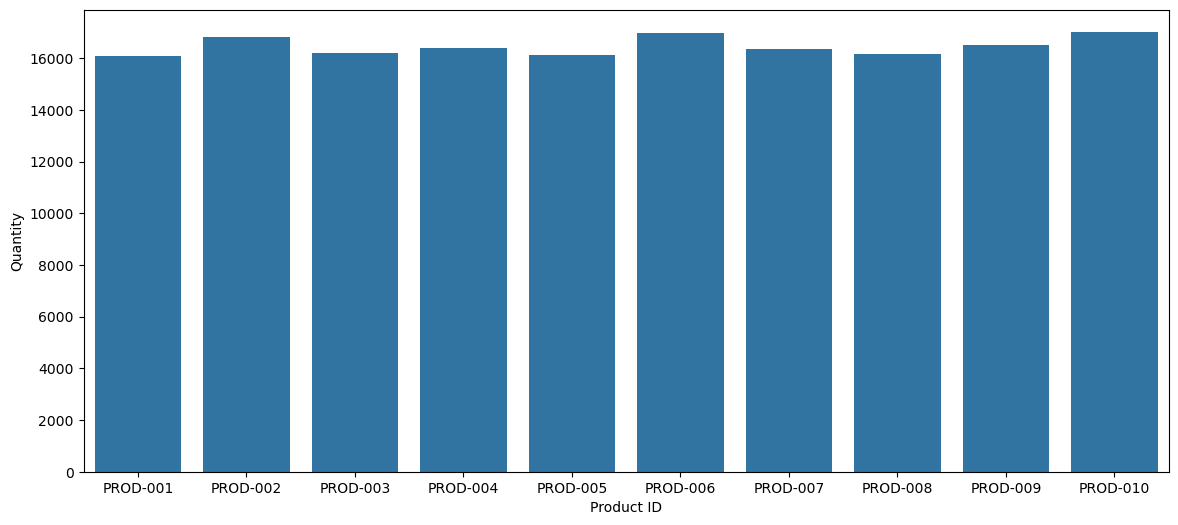

In [58]:
plt.figure(figsize=(14,6))
values=data_set.groupby('Product ID')['Quantity'].sum().reset_index()
sns.barplot(x='Product ID',y='Quantity',data=values)
plt.show()

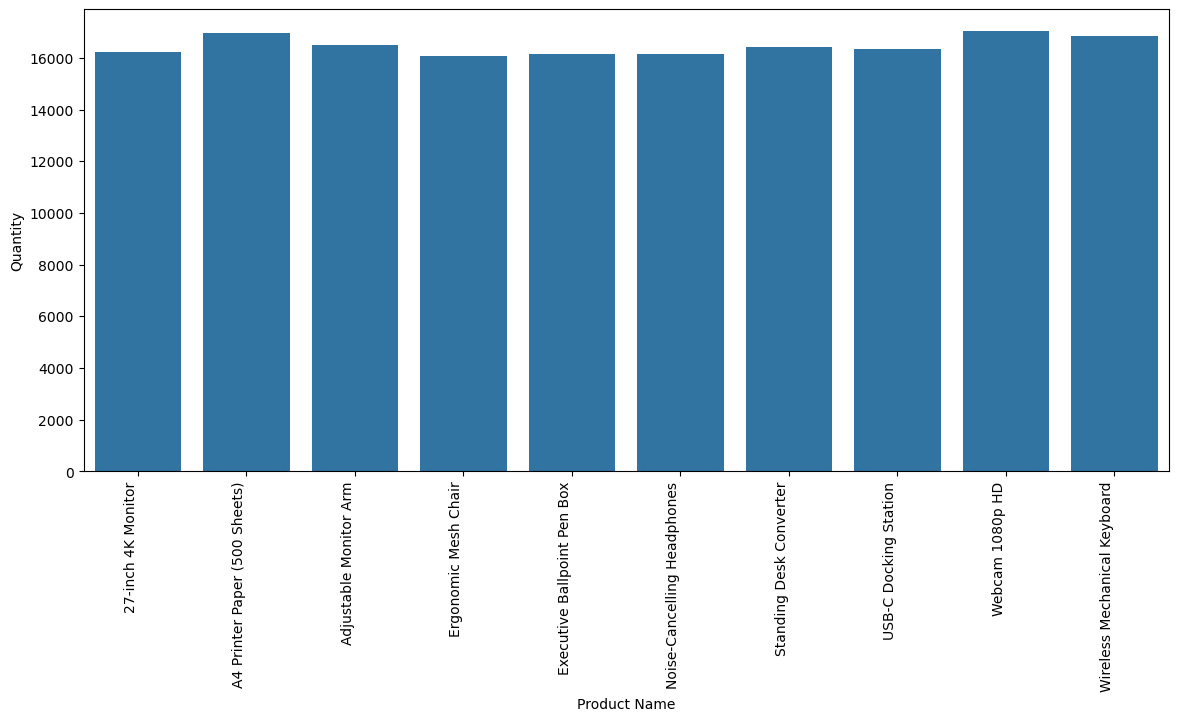

In [59]:
plt.figure(figsize=(14,6))
result=data_set.groupby('Product Name')['Quantity'].sum().reset_index()
sns.barplot(x='Product Name',y='Quantity',data=result)
plt.xticks(rotation=90,ha='right')
plt.show()

Bar Chart:
To compare values between different categories<br>
Pie Chart:
When you want to show percentage or proportion<br>

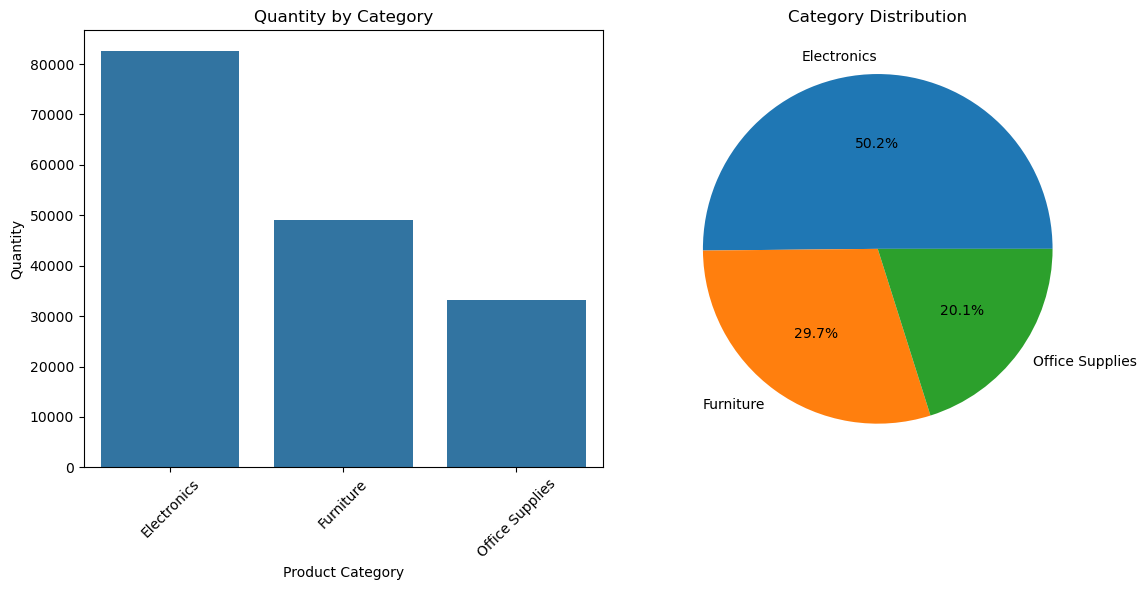

In [60]:
results=data_set.groupby('Product Category')['Quantity'].sum().reset_index()
price_count=data_set['Product Category'].value_counts()

# Create Subplots(1 row, 2 columns)
fig, ax=plt.subplots(1,2,figsize=(12,6))

# --------------BAr Plot-------------------
sns.barplot(x='Product Category',y='Quantity',data=results,ax=ax[0])
ax[0].set_title('Quantity by Category')
ax[0].tick_params(axis='x',rotation=45)

# ---------------Pie Chart-----------------
ax[1].pie(price_count,labels=price_count.index,autopct='%1.1f%%')
ax[1].set_title('Category Distribution')

plt.tight_layout()
plt.show()

Count Plot:<br>
A countplot displays how many times each category appears.

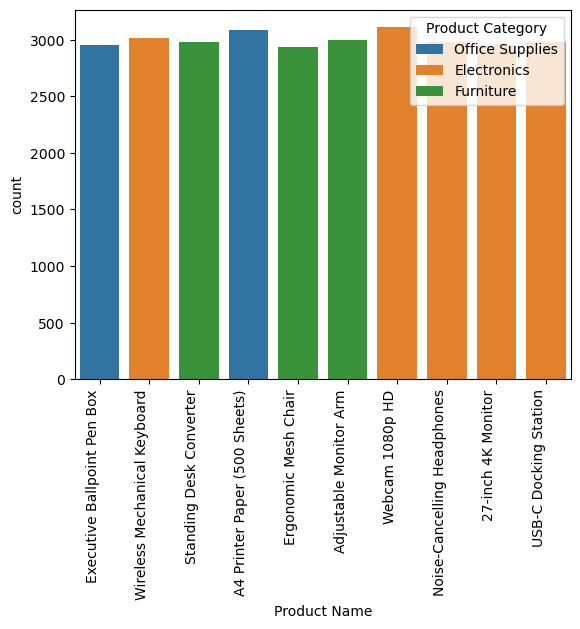

In [61]:
sns.countplot(x='Product Name',data=data_set,hue='Product Category')
plt.xticks(rotation=90,ha='right')
plt.show()

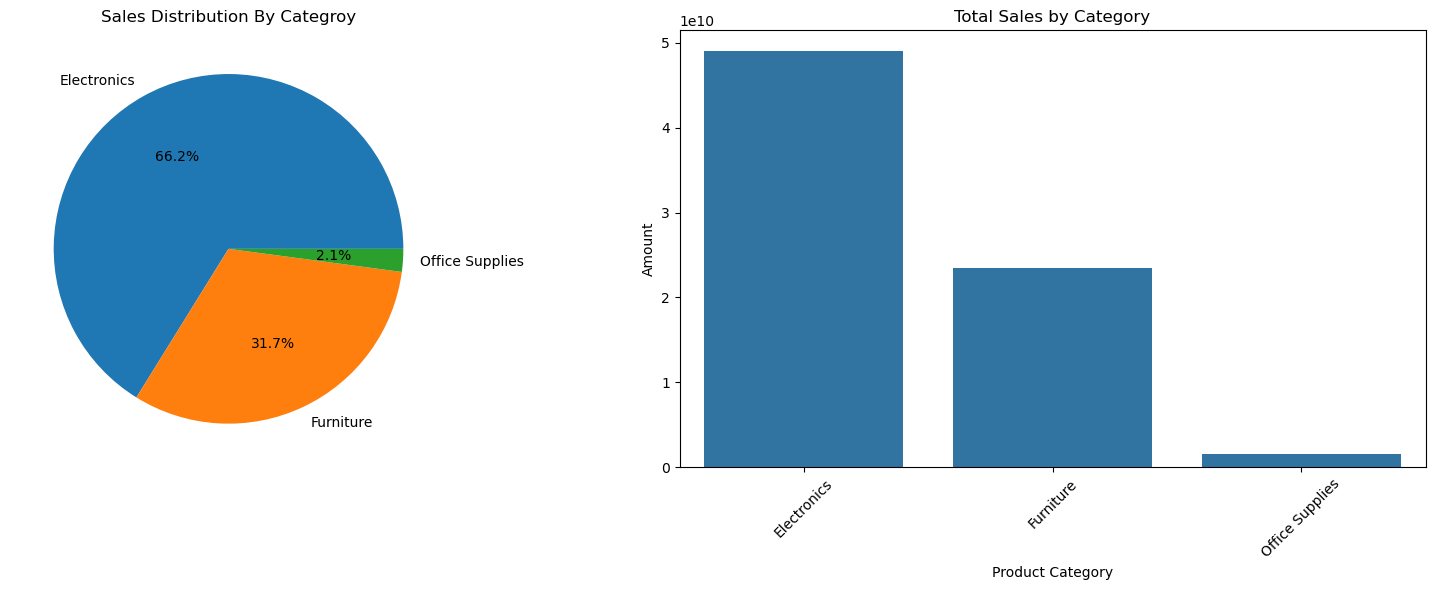

In [62]:
data_set['Amount'] = data_set['Amount'].astype(str).str.replace(',', '')
data_set['Amount']=pd.to_numeric(data_set['Amount'],errors='coerce')

results=data_set.groupby('Product Category')['Amount'].sum().reset_index()

fig, ax=plt.subplots(1,2,figsize=(16,6))

# -----Pie Chart----
ax[0].pie(results['Amount'],labels=results['Product Category'],autopct='%1.1f%%')
ax[0].set_title('Sales Distribution By Categroy')

# ------Bar Plot-----
sns.barplot(x='Product Category',y='Amount',data=results,ax=ax[1])
ax[1].set_title('Total Sales by Category')
ax[1].tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Unique Year
data_set['Date'] = pd.to_datetime(data_set['Date'], dayfirst=True)

unique_years = data_set['Date'].dt.year.unique()

print("Unique years in the dataset:", unique_years)

Unique years in the dataset: [2025]


In [ ]:
# Unique Months
data_set['Date']=pd.to_datetime(data_set['Date'],dayfirst=True)
unique_months=data_set['Date'].dt.month.unique()
print('Unique Month in the Data Set:',unique_months)

Unique Month in the Data Set: [1 2 3 4 5 6]


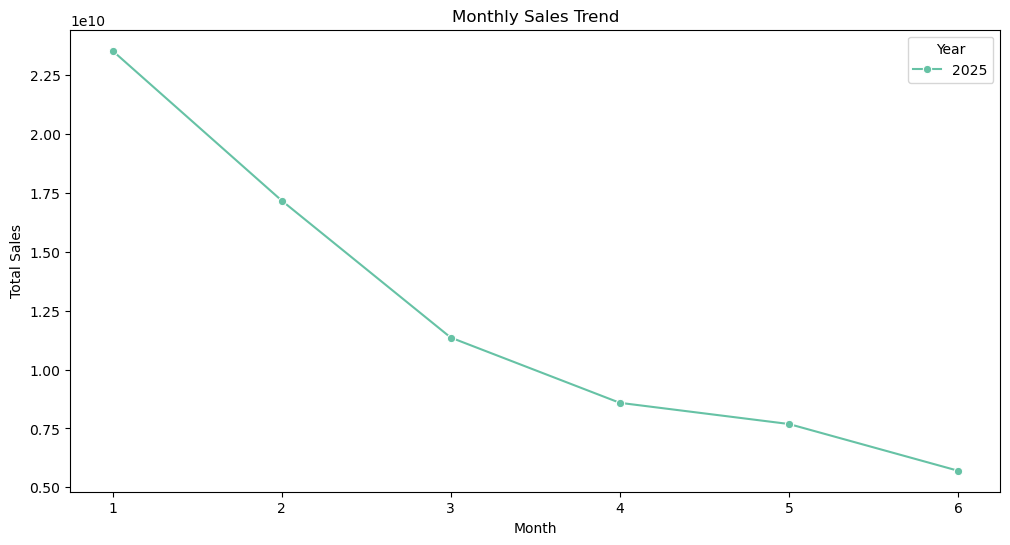

In [ ]:

# convert Date column into datetime format 
data_set['Date'] = pd.to_datetime(data_set['Date'], dayfirst=True)

# Year And Month 
data_set['Year'] = data_set['Date'].dt.year
data_set['Month'] = data_set['Date'].dt.month
data_set['Month_Name'] = data_set['Date'].dt.month_name()

# Sales of Different Months
monthly_sales = data_set.groupby(['Year','Month','Month_Name'])['Amount'].sum().reset_index()

# Maximum Sales in Month
max_sales_month = monthly_sales.loc[
    monthly_sales.groupby('Year')['Amount'].idxmax()
]

# Line plot
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month', y='Amount', hue='Year', marker='o',palette="Set2")
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.xlabel("Month")
plt.show()